In [1]:
!pip install transformers peft accelerate sentencepiece protobuf sentence-transformers umap-learn scikit-learn -q
!pip install torchao --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.4 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, string
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import get_peft_model, LoraConfig
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score
from sklearn.linear_model import Ridge
import umap.umap_ as umap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Connect your google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [5]:
#Change the current working directory
import os
os.chdir('/content/gdrive/My Drive/MARS')

# Print the current working directory
print("Current working directory: {0}".format(os.getcwd()))

Current working directory: /content/gdrive/My Drive/MARS


# Basic Understanding of data

In [6]:
############ Load Dataset ############
df = pd.read_csv("customer_support_tickets.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (20000, 12)

Columns: ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']

Dtypes:
 Ticket_ID                object
Customer_Name            object
Customer_Email           object
Ticket_Subject           object
Ticket_Description       object
Issue_Category           object
Priority_Level           object
Ticket_Channel           object
Submission_Date          object
Resolution_Time_Hours     int64
Assigned_Agent           object
Satisfaction_Score        int64
dtype: object

First 3 rows:


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


### Extract key columns

In [7]:
KEY_COLS = [
    "Ticket_ID",
    "Ticket_Subject",
    "Ticket_Description",
    "Issue_Category",
    "Priority_Level",
    "Ticket_Channel",
    "Resolution_Time_Hours",
    "Satisfaction_Score"
]

df = df[KEY_COLS].copy()
print("Working dataframe shape:", df.shape)
df.head(3)

Working dataframe shape: (20000, 8)


,Ticket_ID,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,Satisfaction_Score
0,TKT-100000,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,5
1,TKT-100001,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,5
2,TKT-100002,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,5


In [8]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)

null_report = pd.DataFrame({
    "null_count": null_counts,
    "null_pct": null_pct
}).sort_values("null_pct", ascending=False)

print(null_report)

                       null_count  null_pct
Ticket_ID                       0       0.0
Ticket_Subject                  0       0.0
Ticket_Description              0       0.0
Issue_Category                  0       0.0
Priority_Level                  0       0.0
Ticket_Channel                  0       0.0
Resolution_Time_Hours           0       0.0
Satisfaction_Score              0       0.0


### Visualisation

In [9]:
priority_order = ["Low", "Medium", "High", "Critical"]
priority_counts = df["Priority_Level"].value_counts().reindex(priority_order)

df["subject_len"] = df["Ticket_Subject"].astype(str).apply(lambda x: len(x.split()))
df["desc_len"] = df["Ticket_Description"].astype(str).apply(lambda x: len(x.split()))

print("Overall text stats:")
print(df[["subject_len", "desc_len"]].describe().round(2))

print("\nAvg description length by priority:")
print(df.groupby("Priority_Level")["desc_len"].mean().round(1).reindex(priority_order))

print("\nAvg resolution time by priority:")
print(df.groupby("Priority_Level")["Resolution_Time_Hours"].mean().round(2).reindex(priority_order))

Overall text stats:
       subject_len  desc_len
count     20000.00  20000.00
mean          4.17     16.93
std           0.38      2.39
min           4.00     10.00
25%           4.00     15.00
50%           4.00     17.00
75%           4.00     19.00
max           5.00     23.00

Avg description length by priority:
Priority_Level
Low         16.6
Medium      16.9
High        17.4
Critical    17.9
Name: desc_len, dtype: float64

Avg resolution time by priority:
Priority_Level
Low         45.17
Medium      44.47
High        24.52
Critical    12.07
Name: Resolution_Time_Hours, dtype: float64


/tmp/ipykernel_3710/3288798566.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


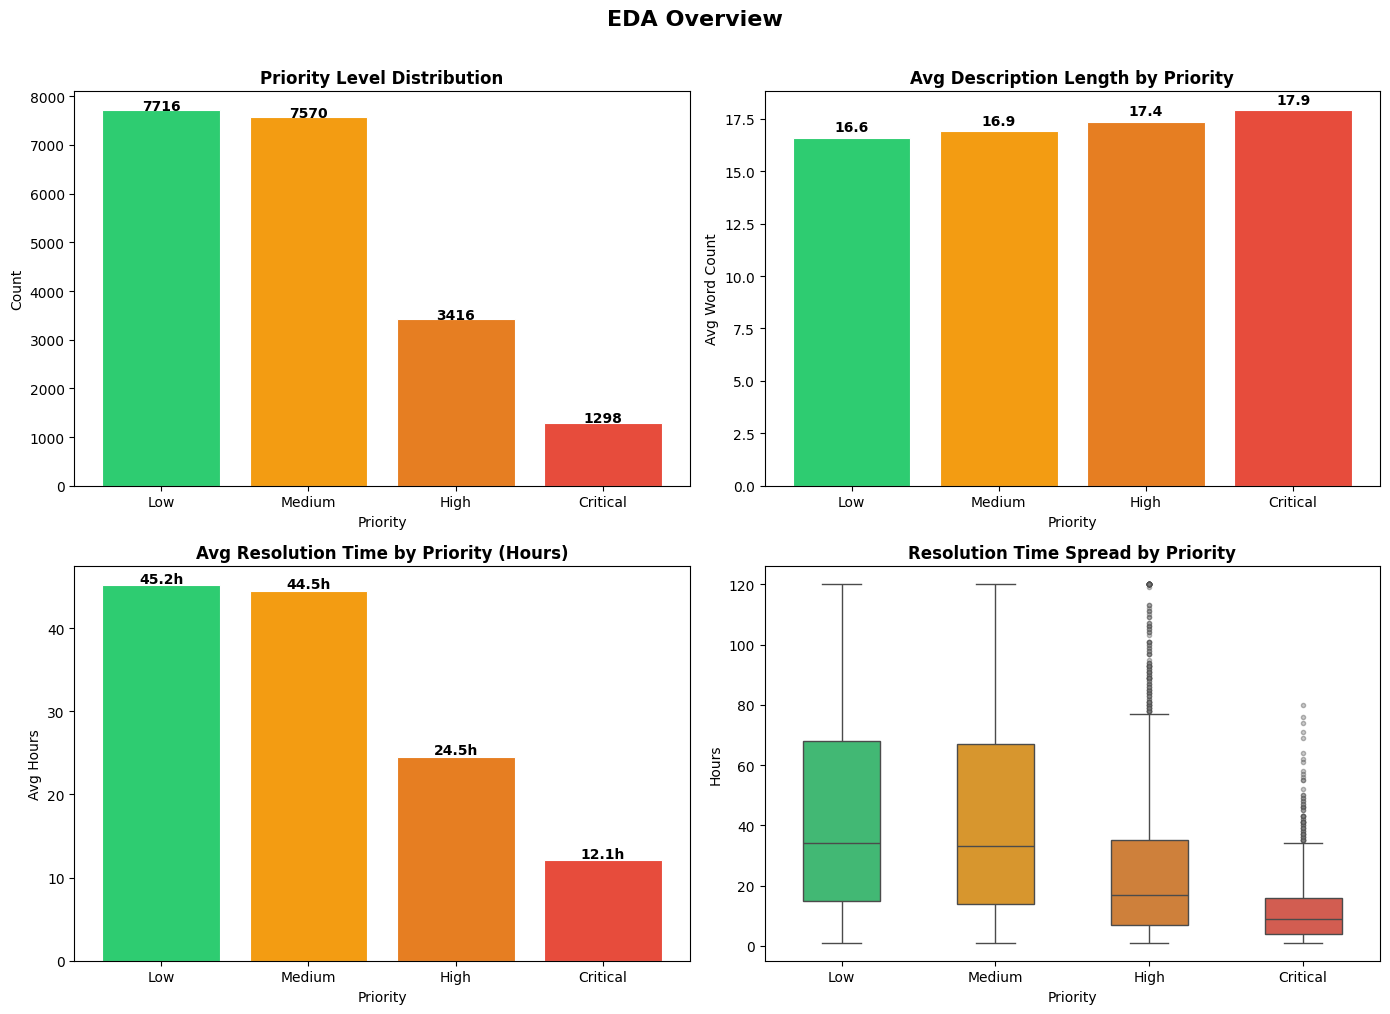

In [10]:
priority_order = ["Low", "Medium", "High", "Critical"]
colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA Overview", fontsize=16, fontweight="bold", y=1.01)

# --- Plot 1: Priority Distribution ---
priority_counts = df["Priority_Level"].value_counts().reindex(priority_order)
axes[0, 0].bar(priority_counts.index, priority_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0, 0].set_title("Priority Level Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Priority")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(priority_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha="center", fontsize=10, fontweight="bold")

# --- Plot 2: Avg Description Length by Priority ---
avg_desc = df.groupby("Priority_Level")["desc_len"].mean().reindex(priority_order)
axes[0, 1].bar(avg_desc.index, avg_desc.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0, 1].set_title("Avg Description Length by Priority", fontweight="bold")
axes[0, 1].set_xlabel("Priority")
axes[0, 1].set_ylabel("Avg Word Count")
for i, v in enumerate(avg_desc.values):
    axes[0, 1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")

# --- Plot 3: Avg Resolution Time by Priority ---
avg_res = df.groupby("Priority_Level")["Resolution_Time_Hours"].mean().reindex(priority_order)
axes[1, 0].bar(avg_res.index, avg_res.values, color=colors, edgecolor="white", linewidth=0.8)
axes[1, 0].set_title("Avg Resolution Time by Priority (Hours)", fontweight="bold")
axes[1, 0].set_xlabel("Priority")
axes[1, 0].set_ylabel("Avg Hours")
for i, v in enumerate(avg_res.values):
    axes[1, 0].text(i, v + 0.3, f"{v:.1f}h", ha="center", fontsize=10, fontweight="bold")

# --- Plot 4: Resolution Time Distribution (Boxplot) ---
priority_palette = dict(zip(priority_order, colors))
sns.boxplot(
    data=df,
    x="Priority_Level",
    y="Resolution_Time_Hours",
    order=priority_order,
    palette=priority_palette,
    ax=axes[1, 1],
    width=0.5,
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.4)
)
axes[1, 1].set_title("Resolution Time Spread by Priority", fontweight="bold")
axes[1, 1].set_xlabel("Priority")
axes[1, 1].set_ylabel("Hours")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3710/2754577415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


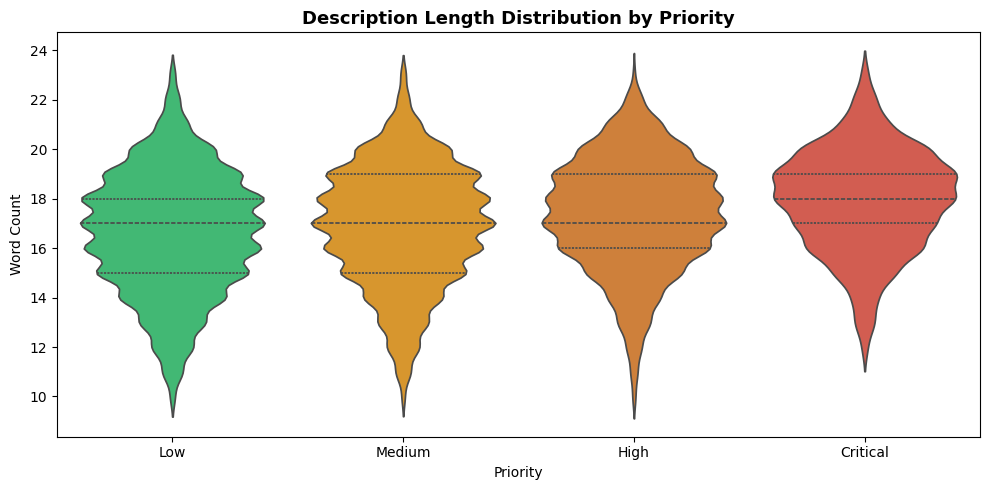

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="Priority_Level",
    y="desc_len",
    order=priority_order,
    palette=priority_palette,
    inner="quartile",
    ax=ax
)
ax.set_title("Description Length Distribution by Priority", fontweight="bold", fontsize=13)
ax.set_xlabel("Priority")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.show()

### Text Preprocessing

In [12]:
import re
import string

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"\S+@\S+", "", text)               # remove emails
    text = re.sub(r"\d+", " ", text)                  # remove standalone numbers
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()          # collapse whitespace
    return text

df["clean_subject"] = df["Ticket_Subject"].apply(clean_text)
df["clean_desc"]    = df["Ticket_Description"].apply(clean_text)

# Combined field — this is what most signals will consume
df["clean_text"] = df["clean_subject"] + " " + df["clean_desc"]

print(df[["Ticket_Subject", "clean_subject", "Ticket_Description", "clean_desc"]].head(3).to_string())

                    Ticket_Subject                  clean_subject                                                                                  Ticket_Description                                                                                       clean_desc
0  Hours of operation - Individual  hours of operation individual                    Hi Support, Where is your headquarters located? Lay soon message show know main.                    hi support where is your headquarters located lay soon message show know main
1          Data not syncing - Card          data not syncing card  Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.  hi support the application crashes every time i open the settings tab speech wall six hour book
2            2FA issues - Question             fa issues question              Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.              hi support how do i upgrade to t

In [13]:
# Spot check a few
for i in range(3):
    print(f"\n--- Ticket {i} ---")
    print("RAW:", df["Ticket_Description"].iloc[i][:200])
    print("CLEAN:", df["clean_text"].iloc[i][:200])


--- Ticket 0 ---
RAW: Hi Support, Where is your headquarters located? Lay soon message show know main.
CLEAN: hours of operation individual hi support where is your headquarters located lay soon message show know main

--- Ticket 1 ---
RAW: Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.
CLEAN: data not syncing card hi support the application crashes every time i open the settings tab speech wall six hour book

--- Ticket 2 ---
RAW: Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.
CLEAN: fa issues question hi support how do i upgrade to the enterprise plan close stand street wear your her


In [14]:
# Check for any empty clean_text after preprocessing
empty_mask = df["clean_text"].str.strip() == ""
print(f"Empty clean_text rows: {empty_mask.sum()}")

# Drop them if any
df = df[~empty_mask].reset_index(drop=True)
print(f"Remaining rows: {len(df)}")

Empty clean_text rows: 0
Remaining rows: 20000


In [15]:
df["clean_text_len"] = df["clean_text"].apply(lambda x: len(x.split()))

print(df["clean_text_len"].describe().round(2))
print("\nAvg cleaned text length by priority:")
print(df.groupby("Priority_Level")["clean_text_len"].mean().round(1).reindex(priority_order))

count    20000.00
mean        19.92
std          2.38
min         13.00
25%         18.00
50%         20.00
75%         22.00
max         27.00
Name: clean_text_len, dtype: float64

Avg cleaned text length by priority:
Priority_Level
Low         19.6
Medium      19.9
High        20.3
Critical    21.0
Name: clean_text_len, dtype: float64


In [16]:
df.head()

,Ticket_ID,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,Satisfaction_Score,subject_len,desc_len,clean_subject,clean_desc,clean_text,clean_text_len
0,TKT-100000,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,5,5,13,hours of operation individual,hi support where is your headquarters located ...,hours of operation individual hi support where...,17
1,TKT-100001,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,5,5,17,data not syncing card,hi support the application crashes every time ...,data not syncing card hi support the applicati...,21
2,TKT-100002,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,5,4,16,fa issues question,hi support how do i upgrade to the enterprise ...,fa issues question hi support how do i upgrade...,19
3,TKT-100003,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,41,5,4,17,login failed let,hi support the dashboard is not loading any da...,login failed let hi support the dashboard is n...,20
4,TKT-100004,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,40,5,4,18,refund status attention,hi support i have been trying to update my pay...,refund status attention hi support i have been...,21


### Encode categorical features

In [17]:
from sklearn.preprocessing import LabelEncoder

print("Unique Priority_Level values:", df["Priority_Level"].unique())
print("\nUnique Ticket_Channel values:", df["Ticket_Channel"].unique())
print("\nUnique Issue_Category values:", df["Issue_Category"].unique())

Unique Priority_Level values: ['High' 'Low' 'Medium' 'Critical']

Unique Ticket_Channel values: ['Web Form' 'Chat' 'Email']

Unique Issue_Category values: ['General Inquiry' 'Technical' 'Account' 'Billing' 'Fraud']


In [18]:
priority_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df["priority_encoded"] = df["Priority_Level"].str.strip().map(priority_map).astype(int)

Split train and test

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["priority_encoded"])

print("Train size:", len(train_df))
print("Test size: ", len(test_df))

Train size: 16000
Test size:  4000


In [20]:
# create encoder
le_channel = LabelEncoder()
train_df["channel_encoded"] = le_channel.fit_transform(train_df["Ticket_Channel"].astype(str))
test_df["channel_encoded"] = le_channel.transform(test_df["Ticket_Channel"].astype(str))

# display mapping
print("Channel mapping:")
print(dict(zip(le_channel.classes_,le_channel.transform(le_channel.classes_))))

Channel mapping:
{'Chat': np.int64(0), 'Email': np.int64(1), 'Web Form': np.int64(2)}


In [21]:
# create encoder
le_category = LabelEncoder()
train_df["category_encoded"] = le_category.fit_transform(train_df["Issue_Category"].astype(str))
test_df["category_encoded"] = le_category.transform(test_df["Issue_Category"].astype(str))

# display mapping
print("\nCategory mapping:")
print(dict(zip(le_category.classes_,le_category.transform(le_category.classes_))))


Category mapping:
{'Account': np.int64(0), 'Billing': np.int64(1), 'Fraud': np.int64(2), 'General Inquiry': np.int64(3), 'Technical': np.int64(4)}


### Normalization

In [22]:
print(df[["Resolution_Time_Hours","Satisfaction_Score"]].describe().round(2))
print("\nNulls in resolution time:", df["Resolution_Time_Hours"].isnull().sum())

       Resolution_Time_Hours  Satisfaction_Score
count               20000.00            20000.00
mean                   39.23                3.72
std                    35.22                1.29
min                     1.00                1.00
25%                    11.00                3.00
50%                    27.00                4.00
75%                    58.00                5.00
max                   120.00                5.00

Nulls in resolution time: 0


In [23]:
scaler = MinMaxScaler()
train_df = train_df.copy()
test_df = test_df.copy()

train_df["resolution_time_norm"] = scaler.fit_transform(train_df[["Resolution_Time_Hours"]])
test_df["resolution_time_norm"]  = scaler.transform(test_df[["Resolution_Time_Hours"]])

print("\nTrain resolution_time_norm stats:")
print(train_df["resolution_time_norm"].describe().round(3))

print("\nTest resolution_time_norm stats:")
print(test_df["resolution_time_norm"].describe().round(3))


Train resolution_time_norm stats:
count    16000.000
mean         0.322
std          0.296
min          0.000
25%          0.084
50%          0.218
75%          0.479
max          1.000
Name: resolution_time_norm, dtype: float64

Test resolution_time_norm stats:
count    4000.000
mean        0.320
std         0.298
min         0.000
25%         0.076
50%         0.227
75%         0.473
max         1.000
Name: resolution_time_norm, dtype: float64


# Embedding-Based Clustering (Signal 1)

In [24]:
print("Loading sentence transformer model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding train embeddings...")
train_embeddings = model.encode(
    train_df["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Encoding test embeddings...")
test_embeddings = model.encode(
    test_df["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Train embeddings shape:", train_embeddings.shape)
print("Test embeddings shape: ", test_embeddings.shape)

Loading sentence transformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding train embeddings...


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Encoding test embeddings...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Train embeddings shape: (16000, 384)
Test embeddings shape:  (4000, 384)


k=2 → silhouette score: 0.0809
k=3 → silhouette score: 0.0919
k=4 → silhouette score: 0.1092
k=5 → silhouette score: 0.1111
k=6 → silhouette score: 0.1048
k=7 → silhouette score: 0.0925
k=8 → silhouette score: 0.1102

Best k: 5


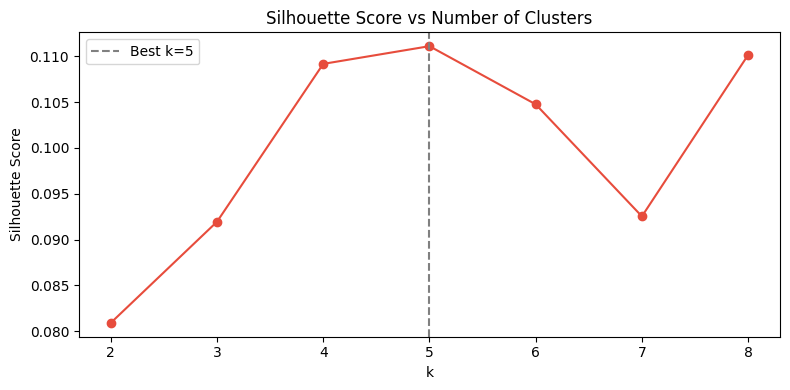

In [25]:
silhouette_scores = {}
for k in range(2, 9):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(train_embeddings)
    score = silhouette_score(train_embeddings, labels, sample_size=2000, random_state=42)
    silhouette_scores[k] = score
    print(f"k={k} → silhouette score: {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k}")

plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="#e74c3c")
plt.axvline(x=best_k, linestyle="--", color="gray", label=f"Best k={best_k}")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_df["cluster"] = kmeans.fit_predict(train_embeddings)
test_df["cluster"]  = kmeans.predict(test_embeddings)

print("Train cluster distribution:")
print(train_df["cluster"].value_counts().sort_index())

print("\nTest cluster distribution:")
print(test_df["cluster"].value_counts().sort_index())

Train cluster distribution:
cluster
0    4175
1    4525
2    2212
3    3272
4    1816
Name: count, dtype: int64

Test cluster distribution:
cluster
0    1048
1    1099
2     538
3     859
4     456
Name: count, dtype: int64


In [27]:
cluster_avg_resolution = train_df.groupby("cluster")["Resolution_Time_Hours"].mean()
median_resolution      = cluster_avg_resolution.median()

binary_severity_map = {
    cluster: (1 if avg_res >= median_resolution else 0)
    for cluster, avg_res in cluster_avg_resolution.items()
}

print("\nCluster → Binary Severity (0=Low-Medium, 1=High-Critical):")
print(binary_severity_map)

train_df["inferred_severity_binary"] = train_df["cluster"].map(binary_severity_map)
test_df["inferred_severity_binary"]  = test_df["cluster"].map(binary_severity_map)

print("\nTrain inferred severity distribution:")
print(train_df["inferred_severity_binary"].value_counts())


Cluster → Binary Severity (0=Low-Medium, 1=High-Critical):
{0: 1, 1: 1, 2: 0, 3: 1, 4: 0}

Train inferred severity distribution:
inferred_severity_binary
1    11972
0     4028
Name: count, dtype: int64


In [28]:
binary_priority_map = {"Low": 0, "Medium": 0, "High": 1, "Critical": 1}

train_df["priority_binary"] = train_df["Priority_Level"].map(binary_priority_map)
test_df["priority_binary"]  = test_df["Priority_Level"].map(binary_priority_map)

print("\nTrain assigned binary priority distribution:")
print(train_df["priority_binary"].value_counts())


Train assigned binary priority distribution:
priority_binary
0    12229
1     3771
Name: count, dtype: int64


In [29]:
print("\nFitting UMAP on train...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
train_2d = reducer.fit_transform(train_embeddings)

print("Transforming test with fitted UMAP...")
test_2d = reducer.transform(test_embeddings)

train_df["umap_x"] = train_2d[:, 0]
train_df["umap_y"] = train_2d[:, 1]
test_df["umap_x"]  = test_2d[:, 0]
test_df["umap_y"]  = test_2d[:, 1]


Fitting UMAP on train...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Transforming test with fitted UMAP...


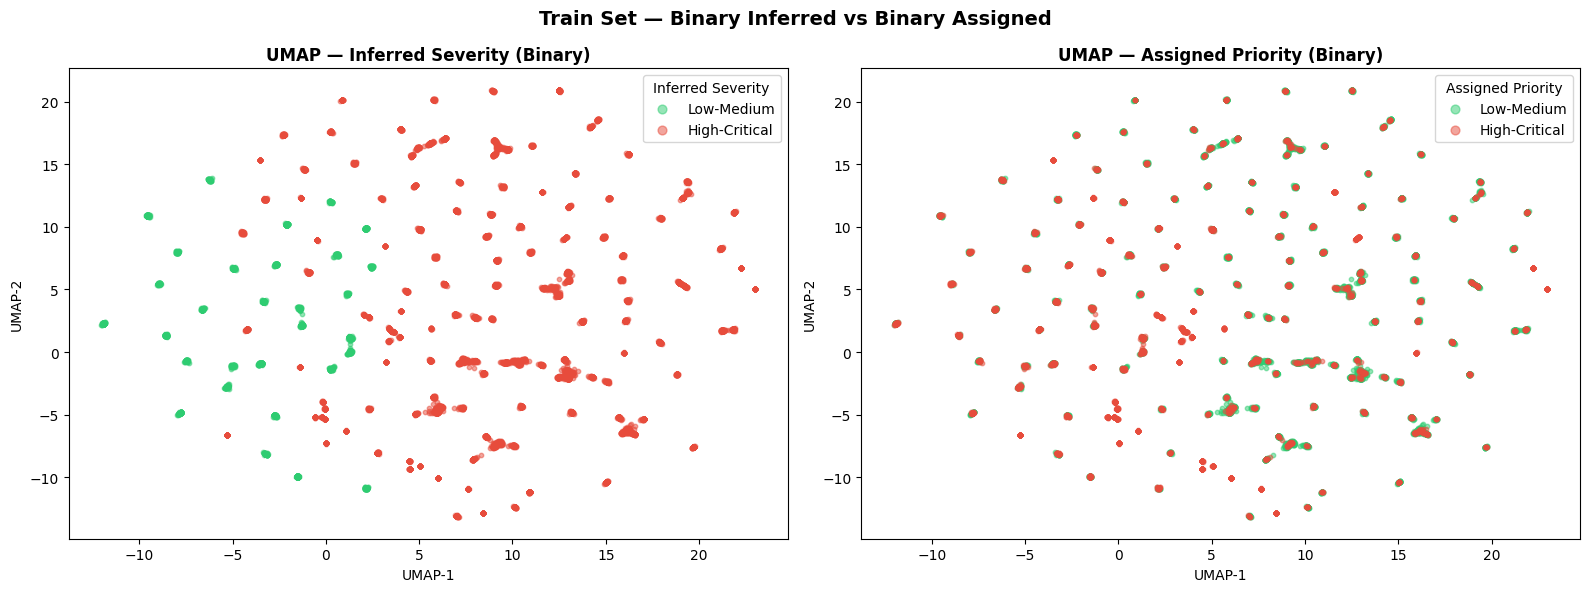

In [30]:
binary_colors = ["#2ecc71", "#e74c3c"]
binary_labels = {0: "Low-Medium", 1: "High-Critical"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sev in [0, 1]:
    mask = train_df["inferred_severity_binary"] == sev
    axes[0].scatter(
        train_df.loc[mask, "umap_x"],
        train_df.loc[mask, "umap_y"],
        c=binary_colors[sev],
        label=binary_labels[sev],
        alpha=0.5, s=10
    )
axes[0].set_title("UMAP — Inferred Severity (Binary)", fontweight="bold")
axes[0].legend(title="Inferred Severity", markerscale=2)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

for sev in [0, 1]:
    mask = train_df["priority_binary"] == sev
    axes[1].scatter(
        train_df.loc[mask, "umap_x"],
        train_df.loc[mask, "umap_y"],
        c=binary_colors[sev],
        label=binary_labels[sev],
        alpha=0.5, s=10
    )
axes[1].set_title("UMAP — Assigned Priority (Binary)", fontweight="bold")
axes[1].legend(title="Assigned Priority", markerscale=2)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.suptitle("Train Set — Binary Inferred vs Binary Assigned", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Generate Mismatch Label

In [31]:
# ── GENERATE MISMATCH LABEL ───────────────────────────────────────────────────
# mismatch = 1 where inferred severity disagrees with assigned priority
# mismatch = 0 where they agree

train_df["mismatch_label"] = (
    train_df["inferred_severity_binary"] != train_df["priority_binary"]
).astype(int)

test_df["mismatch_label"] = (
    test_df["inferred_severity_binary"] != test_df["priority_binary"]
).astype(int)

print("=== TRAIN Mismatch Distribution ===")
train_counts = train_df["mismatch_label"].value_counts()
print(f"Consistent  (0): {train_counts[0]} ({100*train_counts[0]/len(train_df):.1f}%)")
print(f"Mismatch    (1): {train_counts[1]} ({100*train_counts[1]/len(train_df):.1f}%)")

print("\n=== TEST Mismatch Distribution ===")
test_counts = test_df["mismatch_label"].value_counts()
print(f"Consistent  (0): {test_counts[0]} ({100*test_counts[0]/len(test_df):.1f}%)")
print(f"Mismatch    (1): {test_counts[1]} ({100*test_counts[1]/len(test_df):.1f}%)")

=== TRAIN Mismatch Distribution ===
Consistent  (0): 4633 (29.0%)
Mismatch    (1): 11367 (71.0%)

=== TEST Mismatch Distribution ===
Consistent  (0): 1145 (28.6%)
Mismatch    (1): 2855 (71.4%)


In [32]:
def mismatch_type(row):
    if row["mismatch_label"] == 0:
        return "Consistent"
    elif row["inferred_severity_binary"] == 1 and row["priority_binary"] == 0:
        return "Hidden Crisis"    # severe ticket labeled Low/Medium
    elif row["inferred_severity_binary"] == 0 and row["priority_binary"] == 1:
        return "False Alarm"      # non-severe ticket labeled High/Critical
    else:
        return "Unknown"          # safety net — should be 0 rows

train_df["mismatch_type"] = train_df.apply(mismatch_type, axis=1)
test_df["mismatch_type"]  = test_df.apply(mismatch_type, axis=1)

# Verify no unknowns
print("Unknown count:", (train_df["mismatch_type"] == "Unknown").sum())

print("\n=== TRAIN Mismatch Type Breakdown ===")
print(train_df["mismatch_type"].value_counts())

print("\n=== TEST Mismatch Type Breakdown ===")
print(test_df["mismatch_type"].value_counts())

Unknown count: 0

=== TRAIN Mismatch Type Breakdown ===
mismatch_type
Hidden Crisis    9784
Consistent       4633
False Alarm      1583
Name: count, dtype: int64

=== TEST Mismatch Type Breakdown ===
mismatch_type
Hidden Crisis    2459
Consistent       1145
False Alarm       396
Name: count, dtype: int64


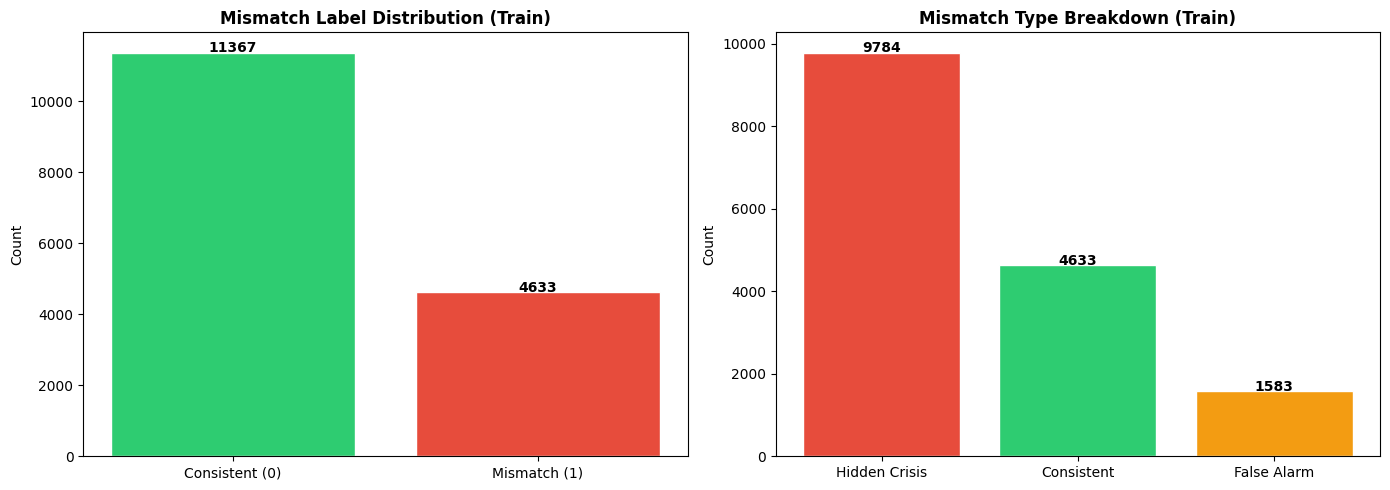

In [33]:
# Visualize mismatch distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary mismatch
mismatch_counts = train_df["mismatch_label"].value_counts()
axes[0].bar(["Consistent (0)", "Mismatch (1)"],
            mismatch_counts.values,
            color=["#2ecc71", "#e74c3c"],
            edgecolor="white")
axes[0].set_title("Mismatch Label Distribution (Train)", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(mismatch_counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

# Mismatch type breakdown
type_counts = train_df["mismatch_type"].value_counts()
colors_type = {"Consistent": "#2ecc71", "Hidden Crisis": "#e74c3c", "False Alarm": "#f39c12"}
axes[1].bar(type_counts.index,
            type_counts.values,
            color=[colors_type[t] for t in type_counts.index],
            edgecolor="white")
axes[1].set_title("Mismatch Type Breakdown (Train)", fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 2, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Resolution Time Regression Signal (Signal 2)

In [34]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

# ── FEATURES: embeddings + metadata (NO resolution time) ─────────────────────
train_meta = np.column_stack([
    train_df["channel_encoded"].values,
    train_df["category_encoded"].values,
    train_df["priority_encoded"].values,   # human label is ok as a feature
])

test_meta = np.column_stack([
    test_df["channel_encoded"].values,
    test_df["category_encoded"].values,
    test_df["priority_encoded"].values,
])

# Concatenate embeddings + metadata
X_train_reg = np.hstack([train_embeddings, train_meta])
X_test_reg  = np.hstack([test_embeddings,  test_meta])

# Target: actual resolution time (normalized) — fit scaler on train only
from sklearn.preprocessing import MinMaxScaler
scaler_reg = MinMaxScaler()
y_train_reg = scaler_reg.fit_transform(
    train_df[["Resolution_Time_Hours"]]
).ravel()
y_test_reg = scaler_reg.transform(
    test_df[["Resolution_Time_Hours"]]
).ravel()

print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape: ", X_test_reg.shape)

X_train_reg shape: (16000, 387)
X_test_reg shape:  (4000, 387)


In [35]:
# ── TRAIN RIDGE REGRESSION ────────────────────────────────────────────────────
reg = Ridge(alpha=1.0)
reg.fit(X_train_reg, y_train_reg)

train_df["predicted_resolution_norm"] = reg.predict(X_train_reg)
test_df["predicted_resolution_norm"]  = reg.predict(X_test_reg)

train_mae = mean_absolute_error(y_train_reg, train_df["predicted_resolution_norm"])
test_mae  = mean_absolute_error(y_test_reg,  test_df["predicted_resolution_norm"])
train_r2  = r2_score(y_train_reg, train_df["predicted_resolution_norm"])
test_r2   = r2_score(y_test_reg,  test_df["predicted_resolution_norm"])

print(f"Train MAE: {train_mae:.4f} | R²: {train_r2:.4f}")
print(f"Test  MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

Train MAE: 0.2265 | R²: 0.0887
Test  MAE: 0.2297 | R²: 0.0608


In [36]:
# ── BINARY SEVERITY FROM REGRESSION ──────────────────────────────────────────
train_median_pred = train_df["predicted_resolution_norm"].median()
print(f"Train median predicted resolution: {train_median_pred:.4f}")

train_df["reg_severity_binary"] = (
    train_df["predicted_resolution_norm"] >= train_median_pred
).astype(int)

test_df["reg_severity_binary"] = (
    test_df["predicted_resolution_norm"] >= train_median_pred  # train threshold
).astype(int)

print("\nTrain reg severity distribution:")
print(train_df["reg_severity_binary"].value_counts())

print("\nTest reg severity distribution:")
print(test_df["reg_severity_binary"].value_counts())

Train median predicted resolution: 0.3335

Train reg severity distribution:
reg_severity_binary
0    8000
1    8000
Name: count, dtype: int64

Test reg severity distribution:
reg_severity_binary
0    2062
1    1938
Name: count, dtype: int64


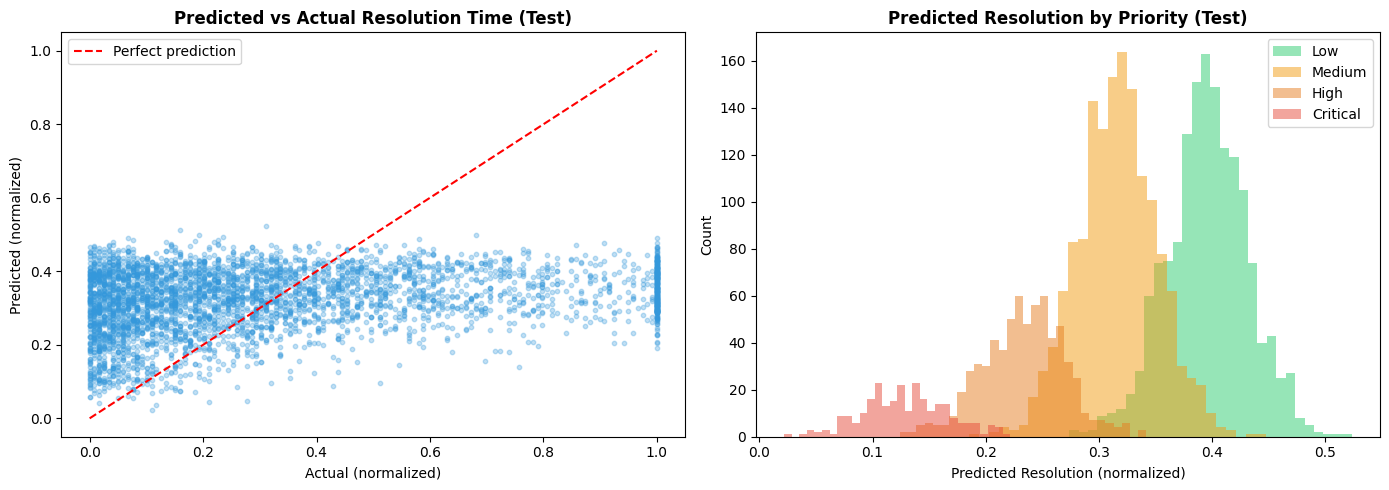

In [37]:
# ── VISUALIZE ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, test_df["predicted_resolution_norm"],
                alpha=0.3, s=10, color="#3498db")
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Predicted vs Actual Resolution Time (Test)", fontweight="bold")
axes[0].set_xlabel("Actual (normalized)")
axes[0].set_ylabel("Predicted (normalized)")
axes[0].legend()

for i, p in enumerate(["Low", "Medium", "High", "Critical"]):
    mask = test_df["Priority_Level"] == p
    axes[1].hist(test_df.loc[mask, "predicted_resolution_norm"],
                 bins=30, alpha=0.5, label=p,
                 color=["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"][i])
axes[1].set_title("Predicted Resolution by Priority (Test)", fontweight="bold")
axes[1].set_xlabel("Predicted Resolution (normalized)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

# Fuse the Signals

In [38]:
# ── BETTER FUSION: AGREEMENT-BASED ───────────────────────────────────────────
# Both signals agree High   → definitely High (1)
# Both signals agree Low    → definitely Low  (0)
# Signals disagree          → trust embedding clustering (stronger signal)

def fuse_signals(row):
    s1 = row["inferred_severity_binary"]   # embedding clustering
    s2 = row["reg_severity_binary"]        # resolution regression
    if s1 == s2:
        return s1          # both agree → use agreed value
    else:
        return s1          # disagree  → trust clustering (stronger signal)

train_df["fused_severity"] = train_df.apply(fuse_signals, axis=1)
test_df["fused_severity"]  = test_df.apply(fuse_signals, axis=1)

# Agreement rate between signals
agreement = (train_df["inferred_severity_binary"] == train_df["reg_severity_binary"]).mean()
print(f"Signal agreement rate: {agreement:.4f} ({agreement*100:.1f}%)")

print("\nFused severity distribution (train):")
print(train_df["fused_severity"].value_counts())

Signal agreement rate: 0.5979 (59.8%)

Fused severity distribution (train):
fused_severity
1    11972
0     4028
Name: count, dtype: int64


In [39]:
# ── PROPER ABLATION — measure mismatch detection, not agreement with human ───
from sklearn.metrics import f1_score, classification_report

# We evaluate: how different is each signal from human labels
# Higher mismatch rate + consistent mismatch type = stronger auditing signal

print("=== ABLATION STUDY (Train) ===\n")

for name, col in [
    ("Signal 1 — Embedding Clustering", "inferred_severity_binary"),
    ("Signal 2 — Resolution Regression", "reg_severity_binary"),
    ("Fused Signal",                     "fused_severity"),
]:
    mismatch_rate = (train_df[col] != train_df["priority_binary"]).mean()
    hidden_crisis = ((train_df[col] == 1) & (train_df["priority_binary"] == 0)).sum()
    false_alarm   = ((train_df[col] == 0) & (train_df["priority_binary"] == 1)).sum()
    signal_agree  = (train_df[col] == train_df["inferred_severity_binary"]).mean()

    print(f"── {name}")
    print(f"   Mismatch rate:   {mismatch_rate:.4f} ({mismatch_rate*100:.1f}%)")
    print(f"   Hidden Crisis:   {hidden_crisis}")
    print(f"   False Alarm:     {false_alarm}")
    print(f"   Agreement w/ S1: {signal_agree:.4f}")
    print()

=== ABLATION STUDY (Train) ===

── Signal 1 — Embedding Clustering
   Mismatch rate:   0.7104 (71.0%)
   Hidden Crisis:   9784
   False Alarm:     1583
   Agreement w/ S1: 1.0000

── Signal 2 — Resolution Regression
   Mismatch rate:   0.7349 (73.5%)
   Hidden Crisis:   7994
   False Alarm:     3765
   Agreement w/ S1: 0.5979

── Fused Signal
   Mismatch rate:   0.7104 (71.0%)
   Hidden Crisis:   9784
   False Alarm:     1583
   Agreement w/ S1: 1.0000



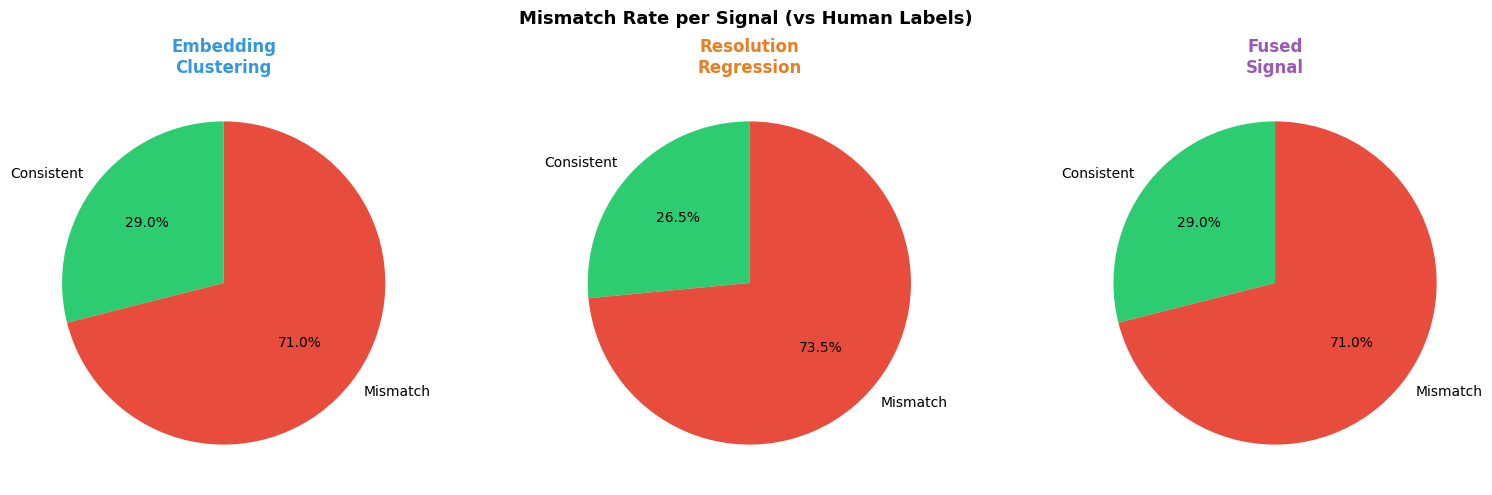

In [40]:
# ── SIGNAL AGREEMENT VISUALIZATION ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

signal_names = ["Embedding\nClustering", "Resolution\nRegression", "Fused\nSignal"]
signal_cols  = ["inferred_severity_binary", "reg_severity_binary", "fused_severity"]
colors       = ["#3498db", "#e67e22", "#9b59b6"]

for i, (name, col) in enumerate(zip(signal_names, signal_cols)):
    mismatch = (train_df[col] != train_df["priority_binary"]).mean()
    consistent = 1 - mismatch
    axes[i].pie(
        [consistent, mismatch],
        labels=["Consistent", "Mismatch"],
        colors=["#2ecc71", "#e74c3c"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[i].set_title(name, fontweight="bold", color=colors[i])

plt.suptitle("Mismatch Rate per Signal (vs Human Labels)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [41]:
print("=== PHASE 2 OUTPUT SUMMARY ===")
print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"\nTrain mismatch_label distribution:")
print(train_df["mismatch_label"].value_counts())
print(f"\nTest mismatch_label distribution:")
print(test_df["mismatch_label"].value_counts())
print(f"\nNull check — train:")
print(train_df[["fused_severity", "mismatch_label", "mismatch_type"]].isnull().sum())

=== PHASE 2 OUTPUT SUMMARY ===
Train rows: 16000 | Test rows: 4000

Train columns: ['Ticket_ID', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Resolution_Time_Hours', 'Satisfaction_Score', 'subject_len', 'desc_len', 'clean_subject', 'clean_desc', 'clean_text', 'clean_text_len', 'priority_encoded', 'channel_encoded', 'category_encoded', 'resolution_time_norm', 'cluster', 'inferred_severity_binary', 'priority_binary', 'umap_x', 'umap_y', 'mismatch_label', 'mismatch_type', 'predicted_resolution_norm', 'reg_severity_binary', 'fused_severity']

Train mismatch_label distribution:
mismatch_label
1    11367
0     4633
Name: count, dtype: int64

Test mismatch_label distribution:
mismatch_label
1    2855
0    1145
Name: count, dtype: int64

Null check — train:
fused_severity    0
mismatch_label    0
mismatch_type     0
dtype: int64


# Classifier Training

In [42]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import get_peft_model, LoraConfig
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, recall_score)
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)  # must print cuda

Device: cuda


In [43]:
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

required = ["clean_text", "mismatch_label",
            "channel_encoded", "category_encoded", "resolution_time_norm"]

for col in required:
    status = "✅" if col in train_df.columns else "❌"
    print(f"{status} {col}")

print("\nMismatch distribution (train):")
print(train_df["mismatch_label"].value_counts())

Train shape: (16000, 28)
Test shape:  (4000, 28)
✅ clean_text
✅ mismatch_label
✅ channel_encoded
✅ category_encoded
✅ resolution_time_norm

Mismatch distribution (train):
mismatch_label
1    11367
0     4633
Name: count, dtype: int64


In [44]:
MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LEN    = 128
BATCH_SIZE = 32

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded ✅")


class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts      = df["clean_text"].tolist()
        self.labels     = df["mismatch_label"].tolist()
        self.channels   = df["channel_encoded"].tolist()
        self.categories = df["category_encoded"].tolist()
        self.res_times  = df["resolution_time_norm"].tolist()
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "channel":        torch.tensor(self.channels[idx],   dtype=torch.float),
            "category":       torch.tensor(self.categories[idx], dtype=torch.float),
            "res_time":       torch.tensor(self.res_times[idx],  dtype=torch.float),
            "label":          torch.tensor(self.labels[idx],     dtype=torch.long)
        }

Loading tokenizer...
Tokenizer loaded ✅


In [45]:
# Full dataset — no subsampling needed on GPU
train_dataset = TicketDataset(train_df, tokenizer, MAX_LEN)
test_dataset  = TicketDataset(test_df,  tokenizer, MAX_LEN)

train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True
)
test_loader   = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Sanity check one sample
sample = train_dataset[0]
print("\nSample keys:     ", list(sample.keys()))
print("input_ids shape: ", sample["input_ids"].shape)
print("label:           ", sample["label"].item())

Train batches: 500
Test batches:  125

Sample keys:      ['input_ids', 'attention_mask', 'channel', 'category', 'res_time', 'label']
input_ids shape:  torch.Size([128])
label:            1


In [46]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    target_modules=["query_proj", "value_proj"],
    inference_mode=False
)


class DeBERTaLoRAWithMetadata(nn.Module):
    def __init__(self, model_name, lora_config, n_metadata=3, n_classes=2, dropout=0.3):
        super().__init__()
        base_model      = AutoModel.from_pretrained(model_name)
        self.deberta    = get_peft_model(base_model, lora_config)
        self.deberta.print_trainable_parameters()
        hidden_size     = base_model.config.hidden_size  # 768

        self.meta_proj  = nn.Sequential(
            nn.Linear(n_metadata, 32),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 32, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, input_ids, attention_mask, channel, category, res_time):
        outputs    = self.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = outputs.last_hidden_state[:, 0, :]          # (batch, 768)
        meta       = torch.stack([channel, category, res_time], dim=1)  # (batch, 3)
        meta_out   = self.meta_proj(meta)                                # (batch, 32)
        combined   = torch.cat([cls_output, meta_out], dim=1)           # (batch, 800)
        return self.classifier(combined)                                 # (batch, 2)


print("Loading model...")
model_clf = DeBERTaLoRAWithMetadata(MODEL_NAME, lora_config).to(device)
print("Model ready ✅")

Loading model...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 141,451,776 || trainable%: 0.1042
Model ready ✅


In [47]:
EPOCHS = 7
LR     = 1e-5

# Manual class weights — boost Consistent (minority) class
class_weights = torch.tensor([3.5, 1.0], dtype=torch.float).to(device)
print("Class weights → Consistent(0): 3.5 | Mismatch(1): 1.0")
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

print(f"Class weights → Consistent(0): 2.5 | Mismatch(1): 1.0")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_clf.parameters()),
    lr=LR,
    weight_decay=0.01
)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps:  {total_steps}")
print(f"Warmup steps: {warmup_steps}")

Class weights → Consistent(0): 2.5 | Mismatch(1): 1.0
Total steps:  2500
Warmup steps: 250


In [48]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for i, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        channel        = batch["channel"].to(device)
        category       = batch["category"].to(device)
        res_time       = batch["res_time"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, channel, category, res_time)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if (i + 1) % 100 == 0:
            print(f"  Batch {i+1}/{len(loader)} | Loss: {loss.item():.4f}")

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro")
    )


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            channel        = batch["channel"].to(device)
            category       = batch["category"].to(device)
            res_time       = batch["res_time"].to(device)
            labels         = batch["label"].to(device)

            logits      = model(input_ids, attention_mask, channel, category, res_time)
            loss        = criterion(logits, labels)
            total_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
        all_preds,
        all_labels
    )

In [49]:
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*50}")

    train_loss, train_acc, train_f1 = train_epoch(
        model_clf, train_loader, optimizer, scheduler, criterion, device
    )
    val_loss, val_acc, val_f1, val_preds, val_labels = eval_epoch(
        model_clf, test_loader, criterion, device
    )

    history.append({
        "epoch":      epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss":   val_loss,   "val_acc":   val_acc,   "val_f1":   val_f1
    })

    print(f"\nTrain → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Macro F1: {train_f1:.4f}")
    print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Macro F1: {val_f1:.4f}")


EPOCH 1/5
  Batch 100/500 | Loss: 0.7357
  Batch 200/500 | Loss: 0.6718
  Batch 300/500 | Loss: 0.6624
  Batch 400/500 | Loss: 0.6603
  Batch 500/500 | Loss: 0.6874

Train → Loss: 0.6814 | Acc: 0.5544 | Macro F1: 0.5322
Val   → Loss: 0.6453 | Acc: 0.6625 | Macro F1: 0.6304

EPOCH 2/5
  Batch 100/500 | Loss: 0.6655
  Batch 200/500 | Loss: 0.5579
  Batch 300/500 | Loss: 0.4265
  Batch 400/500 | Loss: 0.5062
  Batch 500/500 | Loss: 0.3629

Train → Loss: 0.5850 | Acc: 0.7402 | Macro F1: 0.7080
Val   → Loss: 0.5409 | Acc: 0.8010 | Macro F1: 0.7698

EPOCH 3/5
  Batch 100/500 | Loss: 0.6169
  Batch 200/500 | Loss: 0.3224
  Batch 300/500 | Loss: 0.3795
  Batch 400/500 | Loss: 0.5347
  Batch 500/500 | Loss: 0.5021

Train → Loss: 0.5306 | Acc: 0.7959 | Macro F1: 0.7672
Val   → Loss: 0.5271 | Acc: 0.8073 | Macro F1: 0.7763

EPOCH 4/5
  Batch 100/500 | Loss: 0.6130
  Batch 200/500 | Loss: 0.4056
  Batch 300/500 | Loss: 0.4211
  Batch 400/500 | Loss: 0.4727
  Batch 500/500 | Loss: 0.4445

Train → 

In [50]:
print("\n=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(
    val_labels, val_preds,
    target_names=["Consistent (0)", "Mismatch (1)"],
    digits=4
))

recalls = recall_score(val_labels, val_preds, average=None)

print("=== VERIFICATION THRESHOLD CHECK ===")
print(f"Accuracy ≥ 0.83:        {'✅' if val_acc    >= 0.83 else '❌'} ({val_acc:.4f})")
print(f"Macro F1 ≥ 0.82:        {'✅' if val_f1     >= 0.82 else '❌'} ({val_f1:.4f})")
print(f"Recall class 0 ≥ 0.78:  {'✅' if recalls[0] >= 0.78 else '❌'} ({recalls[0]:.4f})")
print(f"Recall class 1 ≥ 0.78:  {'✅' if recalls[1] >= 0.78 else '❌'} ({recalls[1]:.4f})")


=== FINAL CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

Consistent (0)     0.6372    0.7607    0.6935      1145
  Mismatch (1)     0.8959    0.8263    0.8597      2855

      accuracy                         0.8075      4000
     macro avg     0.7665    0.7935    0.7766      4000
  weighted avg     0.8219    0.8075    0.8121      4000

=== VERIFICATION THRESHOLD CHECK ===
Accuracy ≥ 0.83:        ❌ (0.8075)
Macro F1 ≥ 0.82:        ❌ (0.7766)
Recall class 0 ≥ 0.78:  ❌ (0.7607)
Recall class 1 ≥ 0.78:  ✅ (0.8263)


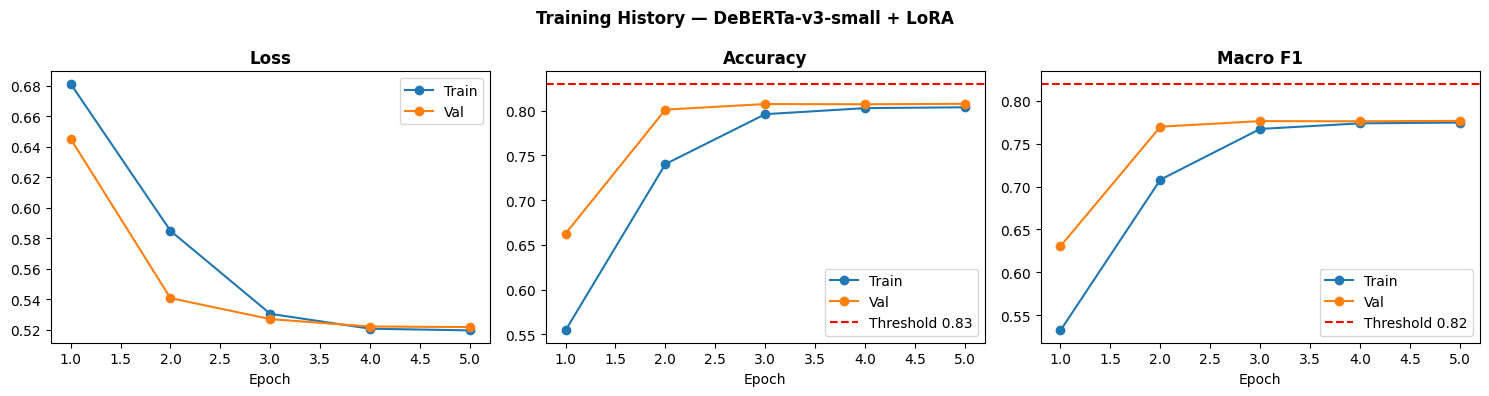

In [51]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   marker="o", label="Val")
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train")
axes[1].plot(history_df["epoch"], history_df["val_acc"],   marker="o", label="Val")
axes[1].axhline(y=0.83, color="red", linestyle="--", label="Threshold 0.83")
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["train_f1"], marker="o", label="Train")
axes[2].plot(history_df["epoch"], history_df["val_f1"],   marker="o", label="Val")
axes[2].axhline(y=0.82, color="red", linestyle="--", label="Threshold 0.82")
axes[2].set_title("Macro F1", fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("Training History — DeBERTa-v3-small + LoRA", fontweight="bold")
plt.tight_layout()
plt.show()

In [52]:
# How many Consistent tickets does the model correctly identify?
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_labels, val_preds)
print("Confusion Matrix:")
print(f"                 Pred Consistent  Pred Mismatch")
print(f"True Consistent       {cm[0][0]}           {cm[0][1]}")
print(f"True Mismatch         {cm[1][0]}          {cm[1][1]}")

# What % of actual Consistent tickets is the model getting wrong?
false_mismatch_rate = cm[0][1] / (cm[0][0] + cm[0][1])
print(f"\nFalse Mismatch rate: {false_mismatch_rate:.4f} ({false_mismatch_rate*100:.1f}%)")
print(f"i.e. model labels {cm[0][1]} Consistent tickets as Mismatch wrongly")

Confusion Matrix:
                 Pred Consistent  Pred Mismatch
True Consistent       871           274
True Mismatch         496          2359

False Mismatch rate: 0.2393 (23.9%)
i.e. model labels 274 Consistent tickets as Mismatch wrongly


In [53]:
# ── STEP 1: Get model confidence on full train set ────────────────────────────
model_clf.eval()
all_probs  = []
all_ids    = []

conf_loader = DataLoader(
    TicketDataset(train_df, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

with torch.no_grad():
    for batch in conf_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        channel        = batch["channel"].to(device)
        category       = batch["category"].to(device)
        res_time       = batch["res_time"].to(device)

        logits = model_clf(input_ids, attention_mask, channel, category, res_time)
        probs  = torch.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
train_df["confidence_score"]     = all_probs.max(axis=1)
train_df["model_pred_label"]     = all_probs.argmax(axis=1)

print("Confidence score distribution:")
print(train_df["confidence_score"].describe().round(3))

Confidence score distribution:
count    16000.000
mean         0.834
std          0.041
min          0.501
25%          0.819
50%          0.842
75%          0.860
max          0.904
Name: confidence_score, dtype: float64


In [54]:
# ── STEP 2: Analyze agreement between model and pseudo-labels ─────────────────
train_df["label_agreement"] = (
    train_df["model_pred_label"] == train_df["mismatch_label"]
).astype(int)

print(f"\nModel agrees with pseudo-label:    {train_df['label_agreement'].sum()} ({train_df['label_agreement'].mean()*100:.1f}%)")
print(f"Model disagrees with pseudo-label: {(1-train_df['label_agreement']).sum()} ({(1-train_df['label_agreement']).mean()*100:.1f}%)")

# Confidence distribution for agree vs disagree
print("\nConfidence when model AGREES with pseudo-label:")
print(train_df[train_df["label_agreement"]==1]["confidence_score"].describe().round(3))

print("\nConfidence when model DISAGREES with pseudo-label:")
print(train_df[train_df["label_agreement"]==0]["confidence_score"].describe().round(3))


Model agrees with pseudo-label:    12898 (80.6%)
Model disagrees with pseudo-label: 3102 (19.4%)

Confidence when model AGREES with pseudo-label:
count    12898.000
mean         0.834
std          0.039
min          0.501
25%          0.820
50%          0.842
75%          0.860
max          0.904
Name: confidence_score, dtype: float64

Confidence when model DISAGREES with pseudo-label:
count    3102.000
mean        0.832
std         0.048
min         0.501
25%         0.819
50%         0.847
75%         0.862
max         0.892
Name: confidence_score, dtype: float64


In [55]:
# ── STEP 3: Filter to high confidence samples only ────────────────────────────
CONFIDENCE_THRESHOLD = 0.75

train_df_confident = train_df[
    train_df["confidence_score"] >= CONFIDENCE_THRESHOLD
].reset_index(drop=True)

print(f"Original train size:    {len(train_df)}")
print(f"High-confidence size:   {len(train_df_confident)}")
print(f"Retained:               {len(train_df_confident)/len(train_df)*100:.1f}%")

print(f"\nLabel distribution in confident subset:")
print(train_df_confident["mismatch_label"].value_counts())

Original train size:    16000
High-confidence size:   15334
Retained:               95.8%

Label distribution in confident subset:
mismatch_label
1    10938
0     4396
Name: count, dtype: int64


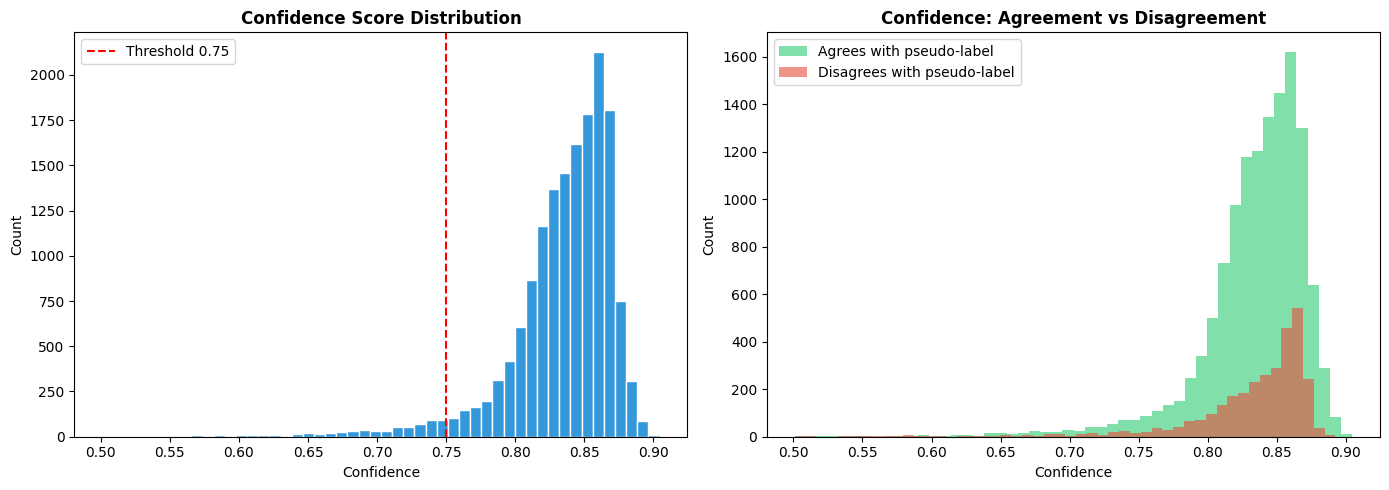

In [56]:
# ── STEP 4: Visualize confidence distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df["confidence_score"], bins=50, color="#3498db", edgecolor="white")
axes[0].axvline(x=CONFIDENCE_THRESHOLD, color="red", linestyle="--",
                label=f"Threshold {CONFIDENCE_THRESHOLD}")
axes[0].set_title("Confidence Score Distribution", fontweight="bold")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")
axes[0].legend()

agree    = train_df[train_df["label_agreement"]==1]["confidence_score"]
disagree = train_df[train_df["label_agreement"]==0]["confidence_score"]
axes[1].hist(agree,    bins=50, alpha=0.6, color="#2ecc71", label="Agrees with pseudo-label")
axes[1].hist(disagree, bins=50, alpha=0.6, color="#e74c3c", label="Disagrees with pseudo-label")
axes[1].set_title("Confidence: Agreement vs Disagreement", fontweight="bold")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [57]:
# ── STEP 5: Retrain on high-confidence subset ─────────────────────────────────
train_dataset_conf = TicketDataset(train_df_confident, tokenizer, MAX_LEN)
train_loader_conf  = DataLoader(
    train_dataset_conf, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=True
)

print(f"New train loader — batches: {len(train_loader_conf)}")

# Recompute class weights from confident subset
class_counts_conf  = train_df_confident["mismatch_label"].value_counts().sort_index().values
class_weights_conf = torch.tensor([3.5, 1.0], dtype=torch.float).to(device)

criterion_conf = nn.CrossEntropyLoss(
    weight=class_weights_conf,
    label_smoothing=0.1
)

# Fresh model
model_clf2 = DeBERTaLoRAWithMetadata(MODEL_NAME, lora_config).to(device)

optimizer2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_clf2.parameters()),
    lr=1e-5,
    weight_decay=0.01
)

EPOCHS2      = 7
total_steps2 = len(train_loader_conf) * EPOCHS2
warmup_steps2 = int(0.1 * total_steps2)

scheduler2 = get_linear_schedule_with_warmup(
    optimizer2,
    num_warmup_steps=warmup_steps2,
    num_training_steps=total_steps2
)

print(f"Total steps: {total_steps2} | Warmup: {warmup_steps2}")

New train loader — batches: 480


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 141,451,776 || trainable%: 0.1042
Total steps: 3360 | Warmup: 336


In [58]:
# ── STEP 6: Run retrain ───────────────────────────────────────────────────────
history2 = []

for epoch in range(1, EPOCHS2 + 1):
    print(f"\n{'='*50}")
    print(f"EPOCH {epoch}/{EPOCHS2}")
    print(f"{'='*50}")

    train_loss, train_acc, train_f1 = train_epoch(
        model_clf2, train_loader_conf,
        optimizer2, scheduler2, criterion_conf, device
    )
    val_loss, val_acc, val_f1, val_preds2, val_labels2 = eval_epoch(
        model_clf2, test_loader, criterion_conf, device
    )

    history2.append({
        "epoch":      epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss":   val_loss,   "val_acc":   val_acc,   "val_f1":   val_f1
    })

    print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")


EPOCH 1/7
  Batch 100/480 | Loss: 0.7914
  Batch 200/480 | Loss: 0.7336
  Batch 300/480 | Loss: 0.7093
  Batch 400/480 | Loss: 0.6323
Train → Loss: 0.7320 | Acc: 0.4923 | F1: 0.4734
Val   → Loss: 0.6828 | Acc: 0.2863 | F1: 0.2225

EPOCH 2/7
  Batch 100/480 | Loss: 0.5918
  Batch 200/480 | Loss: 0.7612
  Batch 300/480 | Loss: 0.7200
  Batch 400/480 | Loss: 0.6381
Train → Loss: 0.6802 | Acc: 0.3158 | F1: 0.2723
Val   → Loss: 0.6646 | Acc: 0.2863 | F1: 0.2225

EPOCH 3/7
  Batch 100/480 | Loss: 0.7055
  Batch 200/480 | Loss: 0.6096
  Batch 300/480 | Loss: 0.6573
  Batch 400/480 | Loss: 0.6633
Train → Loss: 0.6550 | Acc: 0.3653 | F1: 0.3431
Val   → Loss: 0.6216 | Acc: 0.3605 | F1: 0.3351

EPOCH 4/7
  Batch 100/480 | Loss: 0.6072
  Batch 200/480 | Loss: 0.7741
  Batch 300/480 | Loss: 0.6695
  Batch 400/480 | Loss: 0.5035
Train → Loss: 0.6003 | Acc: 0.6440 | F1: 0.6344
Val   → Loss: 0.5867 | Acc: 0.7215 | F1: 0.7006

EPOCH 5/7
  Batch 100/480 | Loss: 0.6749
  Batch 200/480 | Loss: 0.5822
  B

In [59]:
# ── STEP 7: Final evaluation ──────────────────────────────────────────────────
print("\n=== FINAL CLASSIFICATION REPORT (Confidence Filtered) ===")
print(classification_report(
    val_labels2, val_preds2,
    target_names=["Consistent (0)", "Mismatch (1)"],
    digits=4
))

recalls2 = recall_score(val_labels2, val_preds2, average=None)
print("=== VERIFICATION THRESHOLD CHECK ===")
print(f"Accuracy ≥ 0.83:        {'✅' if val_acc    >= 0.83 else '❌'} ({val_acc:.4f})")
print(f"Macro F1 ≥ 0.82:        {'✅' if val_f1     >= 0.82 else '❌'} ({val_f1:.4f})")
print(f"Recall class 0 ≥ 0.78:  {'✅' if recalls2[0] >= 0.78 else '❌'} ({recalls2[0]:.4f})")
print(f"Recall class 1 ≥ 0.78:  {'✅' if recalls2[1] >= 0.78 else '❌'} ({recalls2[1]:.4f})")


=== FINAL CLASSIFICATION REPORT (Confidence Filtered) ===
                precision    recall  f1-score   support

Consistent (0)     0.5573    0.7852    0.6519      1145
  Mismatch (1)     0.8969    0.7499    0.8169      2855

      accuracy                         0.7600      4000
     macro avg     0.7271    0.7675    0.7344      4000
  weighted avg     0.7997    0.7600    0.7696      4000

=== VERIFICATION THRESHOLD CHECK ===
Accuracy ≥ 0.83:        ❌ (0.7600)
Macro F1 ≥ 0.82:        ❌ (0.7344)
Recall class 0 ≥ 0.78:  ✅ (0.7852)
Recall class 1 ≥ 0.78:  ❌ (0.7499)
